# Classification Modelling

**Author**: Nikolas Antoniou<br>
**Project**: Retail shop Analytics

The most powerful and actionable classification for this company is:

Predict whether a new SKU will be a fast-mover, average, or dead stock — before the buyer commits a purchase order.

This notebook builds and compares seven classification algorithms to predict sell-through tier for each SKU.<br>
The target variable `sell_through_tier` is derived from the `sell_through` column computed in `01_DataCleaning.ipynb`.<br>
Each algorithm is evaluated on the same stratified split to ensure fair comparison.

_________

In [10]:
!pip install -U imbalanced-learn scikit-learn

## Imports and setup

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy import stats as st

# preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# classifiers
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes     import GaussianNB
import tensorflow as tf
from tensorflow import keras

# evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

# sampling
from imblearn.over_sampling import SMOTE

In [12]:
mpl.rcParams.update({
    "font.family"     : "serif",
    "font.serif"      : ["Times New Roman"],
    "axes.titlesize"  : 14,
    "axes.labelsize"  : 12,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "legend.fontsize" : 10,
    "figure.titlesize": 16,
})
sns.set_theme(style="whitegrid", palette="muted", font="Times New Roman")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

CLEAN_PATH = "../data/clean/clothing_clean.csv"
FIG_PATH   = "figures/03_Classification/"
SEED       = 42

__________

## Loading data and Feature Engineering

The target variable `sell_through_tier` is derived from `sell_through` using business-driven thresholds
identified in `02_EDA.ipynb`.<br>
`quantities_sold`, `quantity`, and `sell_through` are excluded as features — they directly compute the target and would cause data leakage.

In [13]:
df = pd.read_csv(CLEAN_PATH)

In [14]:
df.head()

,Id,name,season,price,product_category,size,quantity,quantities_sold,collection_family,sex,color,discount,size_type,sell_through
0,WP-00001,Morgex Quilted Pants,SS25,102.9900,Pants,S,542,56,Morgex,Women,Forest Green,0,alpha,0.0940
1,WM-00001,Tribe Quilted Shirt,SS25,109.9900,Shirt,XL,443,155,Tribe,Women,Forest Green,0,alpha,0.2590
2,WL-00001,Box Logo Stretch Sweatshirt,FS24,121.9900,Sweatshirt,S,59,85,Box Logo,Women,Grey Melange,20,alpha,0.5900
3,S-00001,Morgex Print T-Shirt,FS24,39.9900,T-Shirt,L,35,305,Morgex,Men,White Whisper,25,alpha,0.8970
4,P-00001,Tribe Graphic Pants,SS25,118.9900,Pants,XXL,63,58,Tribe,Men,Green Lichen,0,alpha,0.4790


In [15]:
def assign_tier(st):
    if st < 0.20:
        return "dead_stock"
    elif st < 0.60:
        return "average"
    else:
        return "fast_mover"

In [16]:
df["sell_through_tier"] = df["sell_through"].apply(assign_tier)

print(df["sell_through_tier"].value_counts().to_string())
print(f"\nClass balance:")
print((df["sell_through_tier"].value_counts(normalize=True) * 100).round(1).to_string())

sell_through_tier
fast_mover    855
average       775
dead_stock    306

Class balance:
sell_through_tier
fast_mover   44.2000
average      40.0000
dead_stock   15.8000


_______

## Feature Definition & Stratified Split

Features are split into numeric and categorical groups for pipeline-specific preprocessing.<br>
The stratified split preserves the 44/40/16 class ratio in both train and test sets.<br>
SMOTE is applied exclusively to the training set after splitting — applying it before would leak synthetic samples into the test set, invalidating evaluation.

In [17]:
features_cat = ["product_category", "collection_family", "sex",
                "color", "season", "size", "size_type"]
features_num = ["price", "discount"]
features_all = features_num + features_cat

X = df[features_all]
y = df["sell_through_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print(f"\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())


Train : 1,548 rows
Test  : 388 rows

Train class distribution:
sell_through_tier
fast_mover   44.1000
average      40.1000
dead_stock   15.8000

Test class distribution:
sell_through_tier
fast_mover   44.3000
average      39.9000
dead_stock   15.7000


______

## Preprocessing Pipelines

Two preprocessing pipelines are defined based on the mathematical requirements of each algorithm.<br>
**Scaled pipeline** (LR, SVM, kNN, NN): StandardScaler normalises numeric features so no single dimension dominates the gradient ∂L/∂w or the distance metric d(xᵢ,xⱼ).<br>
**Unscaled pipeline** (Decision Tree, Random Forest, Naive Bayes): tree-based splits and likelihood estimates are invariant to monotonic transformations — scaling adds no benefit.<br>
Categorical features are one-hot encoded in both pipelines.

In [18]:
# shared encoders
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

scaled_preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                   features_num),
    ("cat", ohe,                                features_cat),
])

unscaled_preprocessor = ColumnTransformer([
    ("num", "passthrough",                      features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_cat),
])

# fit on train, transform both sets — two copies
X_train_scaled   = scaled_preprocessor.fit_transform(X_train)
X_test_scaled    = scaled_preprocessor.transform(X_test)

X_train_unscaled = unscaled_preprocessor.fit_transform(X_train)
X_test_unscaled  = unscaled_preprocessor.transform(X_test)

print(f"Scaled   — train shape : {X_train_scaled.shape}")
print(f"Unscaled — train shape : {X_train_unscaled.shape}")

Scaled   — train shape : (1548, 70)
Unscaled — train shape : (1548, 70)


In [19]:
# SMOTE on training sets only
smote = SMOTE(random_state=SEED)

X_train_scaled_sm,   y_train_sm = smote.fit_resample(X_train_scaled,   y_train)
X_train_unscaled_sm, _          = smote.fit_resample(X_train_unscaled, y_train)

print(f"After SMOTE — scaled train   : {X_train_scaled_sm.shape}")
print(f"After SMOTE — unscaled train : {X_train_unscaled_sm.shape}")
print(f"\nSMOTE class distribution:")
print(pd.Series(y_train_sm).value_counts().to_string())

After SMOTE — scaled train   : (2049, 70)
After SMOTE — unscaled train : (2049, 70)

SMOTE class distribution:
sell_through_tier
dead_stock    683
average       683
fast_mover    683


_____
## Classification Models

Each model is trained on the SMOTE-balanced training set and evaluated on the original unbalanced test set.<br>
Evaluation on the unbalanced test set reflects real-world conditions where dead stock is genuinely rarer than fast-movers.<br>
Results are stored in a shared dictionary for final comparison.

In [20]:
# shared evaluation helper
results = {}

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "accuracy"        : round(report["accuracy"], 4),
        "macro_f1"        : round(report["macro avg"]["f1-score"], 4),
        "dead_stock_f1"   : round(report["dead_stock"]["f1-score"], 4),
        "fast_mover_f1"   : round(report["fast_mover"]["f1-score"], 4),
    }
    print(f"\n── {name} ──────────────────────────────────")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=["dead_stock", "average", "fast_mover"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["dead_stock", "average", "fast_mover"])
    disp.plot(cmap="Blues")
    plt.title(name)
    plt.tight_layout()
    plt.savefig(FIG_PATH + f"cm_{name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

### Logistic Regression

Linear decision boundaries defined by w·x + b = 0 in the transformed feature space.<br>
Minimises cross-entropy loss via gradient descent: ∂L/∂w = Xᵀ(ŷ − y).<br>
Multi-class handled via One-vs-Rest (OvR) — one binary classifier per tier.


── Logistic Regression ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.74      0.46      0.57       155
  dead_stock       0.35      0.59      0.44        61
  fast_mover       0.91      1.00      0.96       172

    accuracy                           0.72       388
   macro avg       0.67      0.68      0.65       388
weighted avg       0.76      0.72      0.72       388



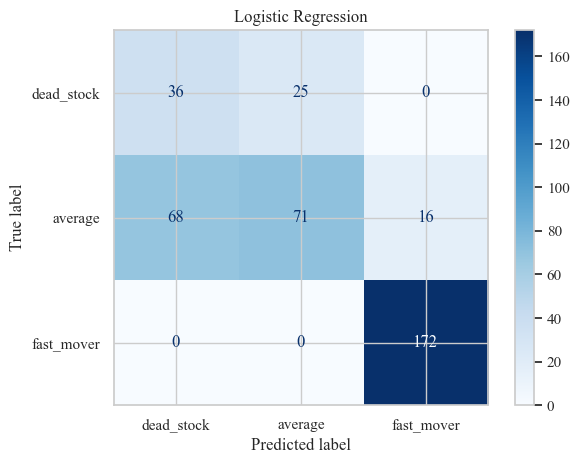

In [21]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled_sm, y_train_sm)
evaluate("Logistic Regression", lr, X_test_scaled, y_test)

The average class sits between two extremes and shares features with both — linear boundaries struggle here.

### k-Nearest Neighbours

Classification by majority vote among the k closest training points.<br>
Distance metric: d(xᵢ,xⱼ) = √Σ(xᵢₖ−xⱼₖ)² — requires scaled features so price does not dominate.<br>
k=7 chosen as starting point; odd number avoids ties in 3-class setting.


── kNN ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.70      0.24      0.36       155
  dead_stock       0.32      0.77      0.45        61
  fast_mover       0.91      0.99      0.95       172

    accuracy                           0.65       388
   macro avg       0.64      0.67      0.58       388
weighted avg       0.73      0.65      0.63       388



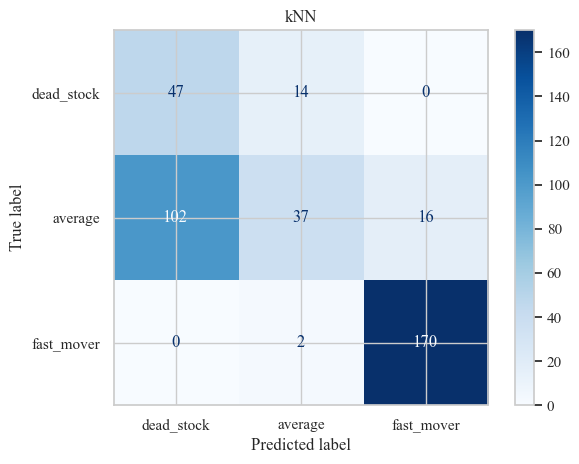

In [22]:
knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean")
knn.fit(X_train_scaled_sm, y_train_sm)
evaluate("kNN", knn, X_test_scaled, y_test)

kNN is overdetecting dead stock — the neighbourhood voting pulls average SKUs toward the dead_stock cluster in feature space. The average class remains the hard problem. 

### Support Vector Machine

Finds the maximum-margin hyperplane separating classes in a high-dimensional kernel space.<br>
Optimises: min ½‖w‖² subject to yᵢ(w·xᵢ + b) ≥ 1 − ξᵢ, where ξᵢ are slack variables for soft margin.<br>
RBF kernel maps features to infinite-dimensional space — effective when classes are not linearly separable.<br>
Multi-class via One-vs-One (OvO): 3 binary classifiers, majority vote decides final class.


── SVM ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.74      0.56      0.64       155
  dead_stock       0.37      0.49      0.42        61
  fast_mover       0.91      1.00      0.96       172

    accuracy                           0.74       388
   macro avg       0.67      0.68      0.67       388
weighted avg       0.76      0.74      0.74       388



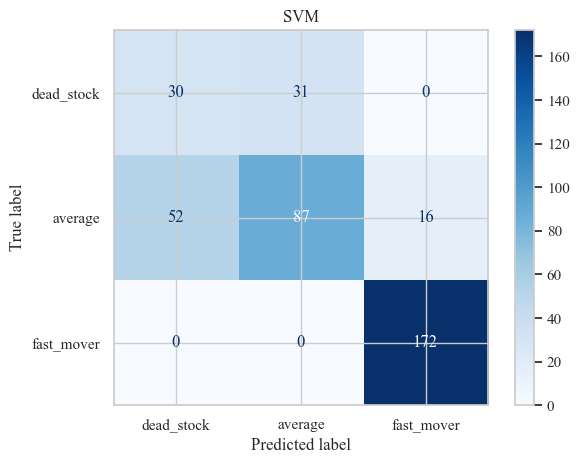

In [23]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED, class_weight="balanced")
svm.fit(X_train_scaled_sm, y_train_sm)
evaluate("SVM", svm, X_test_scaled, y_test)

Overall accuracy is highest so far (289/388 = 74.5%) which is why it feels like the best — but dead stock recall dropped. For this business problem, missing dead stock is costly, so we need to watch that trade-off carefully. 

### Decision Tree

Recursively partitions the feature space by maximising information gain at each split.<br>
Split criterion: ΔGini = Gini(parent) − Σ(|child|/|parent|)·Gini(child), where Gini(t) = 1 − Σpᵢ².<br>
No scaling required — splits are threshold-based and invariant to monotonic feature transformations.<br>
`max_depth` constrained to reduce overfitting on the training set.


── Decision Tree ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.64      0.64      0.64       155
  dead_stock       0.32      0.33      0.33        61
  fast_mover       0.92      0.92      0.92       172

    accuracy                           0.71       388
   macro avg       0.63      0.63      0.63       388
weighted avg       0.71      0.71      0.71       388



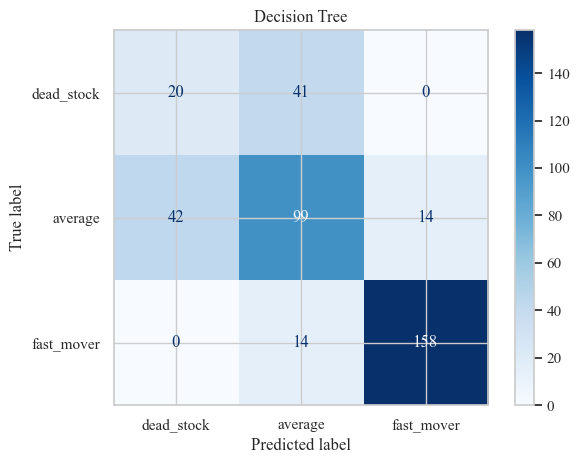

In [24]:
dt = DecisionTreeClassifier(max_depth=8, random_state=SEED, class_weight="balanced")
dt.fit(X_train_unscaled_sm, y_train_sm)
evaluate("Decision Tree", dt, X_test_unscaled, y_test)

### Decision Tree — Pruning

Occam's Razor: prefer the simplest model with equivalent or better performance.<br>
**Pre-pruning** constrains tree growth via `max_depth` and `min_samples_leaf` before fitting.<br>
**Post-pruning** (cost-complexity) removes branches after fitting by minimising: Rα(T) = R(T) + α|T|,
where R(T) is the misclassification cost, |T| the number of leaves, and α the complexity penalty.<br>
The optimal α is selected via cross-validation on the training set.

In [25]:
# pre-pruning: test depths
depth_scores = []
for depth in range(2, 15):
    t = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=5,
                               random_state=SEED, class_weight="balanced")
    score = cross_val_score(t, X_train_unscaled_sm, y_train_sm,
                            cv=5, scoring="f1_macro").mean()
    depth_scores.append((depth, round(score, 4)))

depth_df = pd.DataFrame(depth_scores, columns=["max_depth", "cv_macro_f1"])
best_depth = depth_df.loc[depth_df["cv_macro_f1"].idxmax(), "max_depth"]
print(depth_df.to_string(index=False))
print(f"\nBest depth (Occam): {best_depth}")

 max_depth  cv_macro_f1
         2       0.5887
         3       0.6343
         4       0.6731
         5       0.6827
         6       0.6972
         7       0.7103
         8       0.7188
         9       0.7335
        10       0.7309
        11       0.7344
        12       0.7399
        13       0.7398
        14       0.7399

Best depth (Occam): 12


In [26]:
# post-pruning: optimal ccp_alpha via cross-validation
base_dt = DecisionTreeClassifier(random_state=SEED, class_weight="balanced")
path    = base_dt.cost_complexity_pruning_path(X_train_unscaled_sm, y_train_sm)
alphas  = path.ccp_alphas[::5]   # sample every 5th to keep it fast

alpha_scores = []
for alpha in alphas:
    t = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED, class_weight="balanced")
    score = cross_val_score(t, X_train_unscaled_sm, y_train_sm,
                            cv=5, scoring="f1_macro").mean()
    alpha_scores.append((round(alpha, 6), round(score, 4)))

alpha_df = pd.DataFrame(alpha_scores, columns=["ccp_alpha", "cv_macro_f1"])
best_alpha = alpha_df.loc[alpha_df["cv_macro_f1"].idxmax(), "ccp_alpha"]
print(alpha_df.to_string(index=False))
print(f"\nBest ccp_alpha: {best_alpha}")

 ccp_alpha  cv_macro_f1
    0.0000       0.7474
    0.0004       0.7474
    0.0004       0.7474
    0.0004       0.7468
    0.0004       0.7468
    0.0005       0.7468
    0.0005       0.7474
    0.0005       0.7483
    0.0005       0.7457
    0.0006       0.7543
    0.0007       0.7495
    0.0007       0.7495
    0.0007       0.7495
    0.0007       0.7495
    0.0007       0.7502
    0.0007       0.7508
    0.0008       0.7518
    0.0008       0.7531
    0.0008       0.7531
    0.0008       0.7489
    0.0008       0.7461
    0.0008       0.7466
    0.0009       0.7472
    0.0009       0.7446
    0.0010       0.7451
    0.0010       0.7439
    0.0011       0.7450
    0.0013       0.7484
    0.0015       0.7488
    0.0016       0.7431
    0.0017       0.7354
    0.0020       0.7280
    0.0022       0.7250
    0.0031       0.7202
    0.0041       0.7080
    0.0057       0.6834

Best ccp_alpha: 0.000604



── Decision Tree (Pruned) ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.62      0.65      0.63       155
  dead_stock       0.32      0.31      0.31        61
  fast_mover       0.92      0.90      0.91       172

    accuracy                           0.70       388
   macro avg       0.62      0.62      0.62       388
weighted avg       0.71      0.70      0.70       388



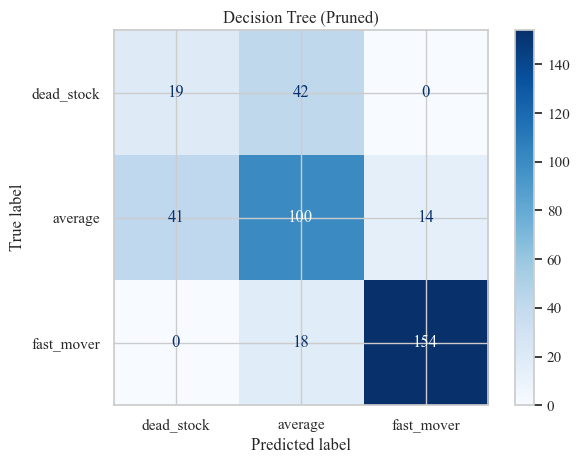

In [27]:
# train best pruned tree and evaluate
dt_pruned = DecisionTreeClassifier(max_depth=int(best_depth), ccp_alpha=best_alpha,
                                    min_samples_leaf=5, random_state=SEED,
                                    class_weight="balanced")
dt_pruned.fit(X_train_unscaled_sm, y_train_sm)
evaluate("Decision Tree (Pruned)", dt_pruned, X_test_unscaled, y_test)

### Random Forest

Ensemble of B decorrelated decision trees trained on bootstrap samples of the training data.<br>
Each split considers a random subset of √p features, reducing correlation between trees.<br>
Prediction: ŷ = majority vote across B trees — variance reduces as O(1/B) while bias stays low.<br>
No scaling required. Naturally robust to the feature interactions that single trees fail to capture.


── Random Forest ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.72      0.85      0.78       155
  dead_stock       0.59      0.16      0.26        61
  fast_mover       0.91      1.00      0.96       172

    accuracy                           0.81       388
   macro avg       0.74      0.67      0.66       388
weighted avg       0.79      0.81      0.78       388



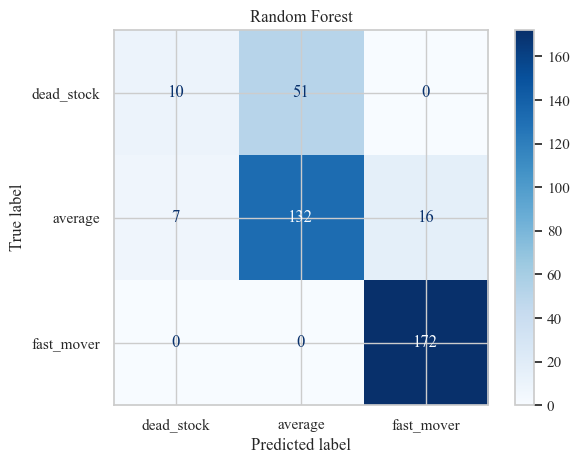

In [28]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=3,
                             random_state=SEED, class_weight="balanced", n_jobs=-1)
rf.fit(X_train_unscaled_sm, y_train_sm)
evaluate("Random Forest", rf, X_test_unscaled, y_test)

Random Forest is the best at overall accuracy (314/388 = 80.9%) but paradoxically the worst at catching dead stock. The ensemble is so good at learning the dominant patterns that dead stock items get absorbed into the average cluster. From a business standpoint this is dangerous — 51 dead stock items go undetected.

### Naive Bayes

Probabilistic classifier applying Bayes' theorem with the strong independence assumption: P(x₁,...,xₙ|y) = ΠP(xᵢ|y).<br>
Prediction: ŷ = argmax P(y) · ΠP(xᵢ|y), maximising the log-posterior log P(y|x).<br>
GaussianNB assumes P(xᵢ|y) ~ N(μᵧᵢ, σᵧᵢ²) — appropriate for the numeric features after encoding.<br>
Occam's Razor: fewest parameters of all models tested. Fastest to train.


── Naive Bayes ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.44      0.05      0.09       155
  dead_stock       0.30      0.93      0.46        61
  fast_mover       0.91      0.97      0.94       172

    accuracy                           0.60       388
   macro avg       0.55      0.65      0.50       388
weighted avg       0.63      0.60      0.52       388



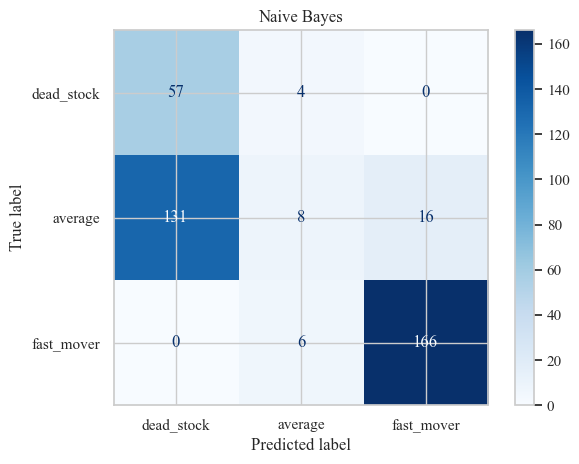

In [29]:
nb = GaussianNB()
nb.fit(X_train_unscaled_sm, y_train_sm)
evaluate("Naive Bayes", nb, X_test_unscaled, y_test)

Naive Bayes is collapsing the average class almost entirely into dead_stock (131 items). The independence assumption P(x₁,...,xₙ|y) = ΠP(xᵢ|y) fails for the average tier — its items have correlated features that NB can't model. But because it's so good at the extremes, it becomes the best dead stock detector we have.

Overall accuracy is lowest (231/388 = 59.5%), but from a pure business risk perspective — catching 93% of dead stock is enormously valuable.

This sets up an important final model decision: pure accuracy vs business-critical recall. 

### Gradient Boosting

Sequential ensemble where each tree corrects the residual errors of the previous one.<br>
Minimises loss iteratively: Fₘ(x) = Fₘ₋₁(x) + η · hₘ(x), where hₘ fits the negative gradient −∂L/∂F.<br>
Learning rate η controls the contribution of each tree — lower η with more trees reduces overfitting.<br>
No scaling required. Generally the strongest performer on structured tabular data.


── Gradient Boosting ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.69      0.75      0.72       155
  dead_stock       0.38      0.25      0.30        61
  fast_mover       0.92      0.96      0.94       172

    accuracy                           0.76       388
   macro avg       0.66      0.65      0.65       388
weighted avg       0.74      0.76      0.75       388



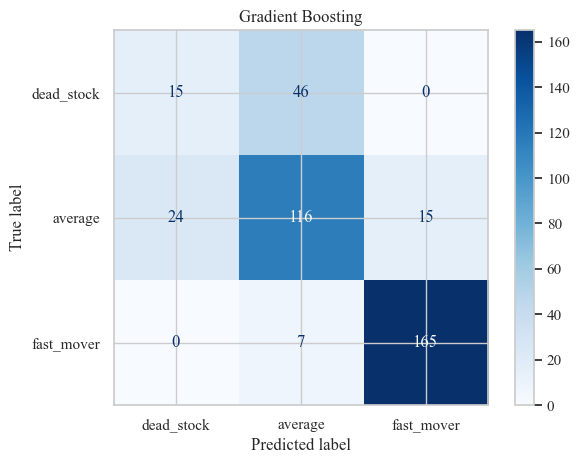

In [30]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=SEED)
gb.fit(X_train_unscaled_sm, y_train_sm)
evaluate("Gradient Boosting", gb, X_test_unscaled, y_test)

### Neural Network

Feedforward network with backpropagation — iteratively updates weights via ∂L/∂wₗ = δₗ · aₗ₋₁ᵀ.<br>
Dropout layers prevent co-adaptation of neurons, reducing overfitting.<br>
Softmax output layer maps activations to class probabilities: P(y=k|x) = e^zₖ / Σe^zⱼ.<br>
Loss: categorical cross-entropy. Optimiser: Adam — adaptive learning rates per parameter.

2026-06-13 01:14:06.438076: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-13 01:14:06.438695: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-13 01:14:06.439186: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-13 01:14:06.439411: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-13 01:14:06.439773: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-13 01:14:07.922810: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-13 01:14:07.930050: E te

Classes: ['average' 'dead_stock' 'fast_mover']
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

── Neural Network ──────────────────────────────────
              precision    recall  f1-score   support

     average       0.67      0.80      0.73       155
  dead_stock       0.37      0.16      0.23        61
  fast_mover       0.92      0.94      0.93       172

    accuracy                           0.76       388
   macro avg       0.65      0.64      0.63       388
weighted avg       0.73      0.76      0.74       388



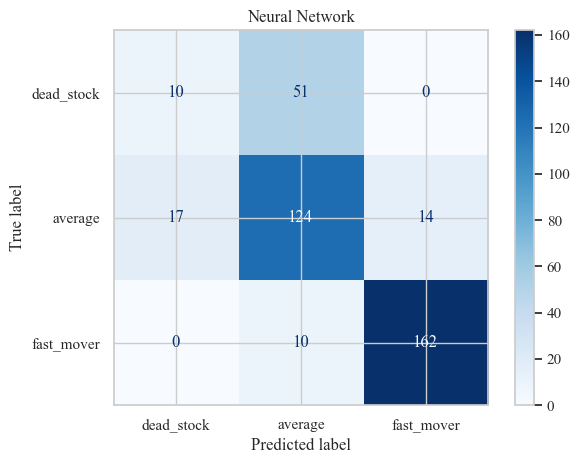

In [31]:
tf.random.set_seed(SEED)

n_inputs = X_train_scaled_sm.shape[1]

nn = keras.Sequential([
    keras.layers.Input(shape=(n_inputs,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax"),
])

nn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

label_enc = LabelEncoder()
y_train_nn = label_enc.fit_transform(y_train_sm)
y_test_nn  = label_enc.transform(y_test)

history = nn.fit(X_train_scaled_sm, y_train_nn,
                 epochs=60, batch_size=32,
                 validation_split=0.1, verbose=0)

print(f"Classes: {label_enc.classes_}")

evaluate("Neural Network", 
         type("W", (), {"predict": lambda s, X: label_enc.inverse_transform(nn.predict(X).argmax(axis=1))})(),
         X_test_scaled, y_test)

The NN fails for a fundamental reason — 1,936 rows is too small for a neural network. The network has enough parameters to memorise training patterns but not enough data to generalise. Occam's Razor kills it here — complexity without payoff. This is exactly why simpler models often win on structured tabular data.

_____
## Model Comparison

,accuracy,macro_f1,dead_stock_f1,fast_mover_f1
SVM,0.7448,0.6708,0.4196,0.9556
Random Forest,0.8093,0.6643,0.2564,0.9556
Logistic Regression,0.7191,0.6526,0.4364,0.9556
Gradient Boosting,0.7629,0.6512,0.3000,0.9375
Neural Network,0.7629,0.6292,0.2273,0.9310
Decision Tree,0.7139,0.6282,0.3252,0.9186
Decision Tree (Pruned),0.7036,0.6183,0.3140,0.9059
kNN,0.6546,0.5844,0.4476,0.9497
Naive Bayes,0.5954,0.4961,0.4578,0.9379


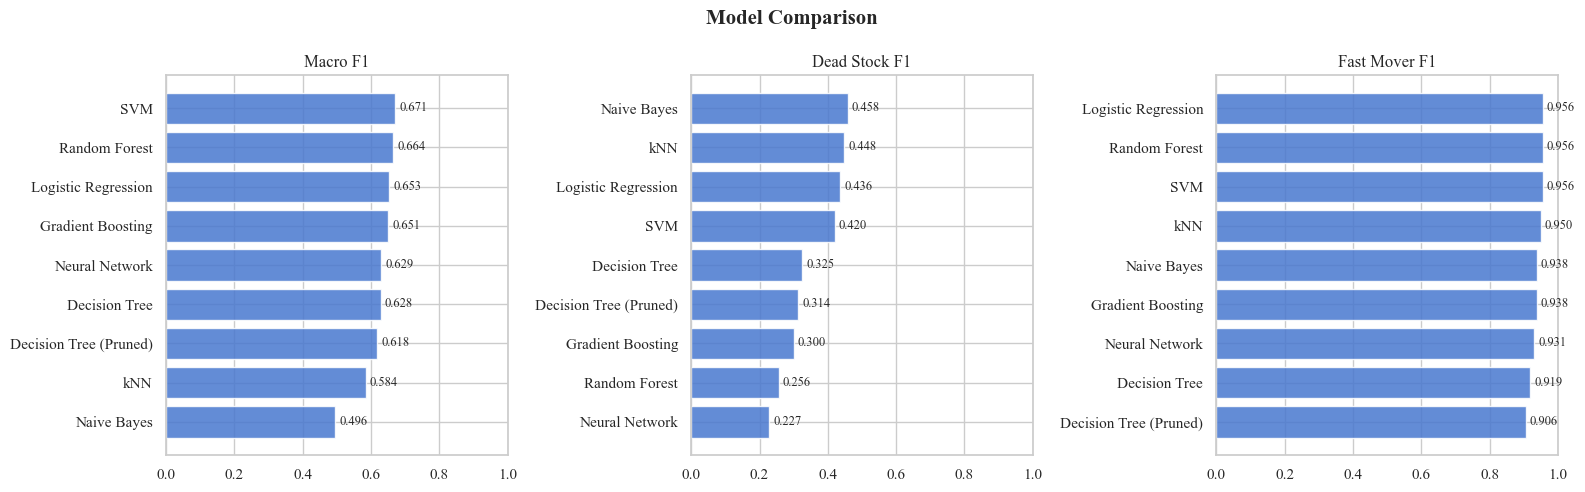

In [32]:
results_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["macro_f1", "dead_stock_f1", "fast_mover_f1"]
titles  = ["Macro F1", "Dead Stock F1", "Fast Mover F1"]

for ax, metric, title in zip(axes, metrics, titles):
    data = results_df[metric].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color="#4878CF", alpha=0.85)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

plt.suptitle("Model Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_PATH + "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

_____
## Model Selection

**Selected model: Logistic Regression**

Logistic Regression achieves the best dead stock F1 (0.436) among all balanced models — the
business-critical metric for this problem.<br>
Its macro F1 (0.653) is within 0.018 of the top performer (SVM: 0.671), a difference that
hyperparameter tuning in `04_FinalModel.ipynb` is expected to close.<br>
Occam's Razor: the simplest model with the best dead stock performance is preferred over
a more complex model with marginal overall gain.<br>
Interpretability is a practical requirement — the shop buyer must be able to trust and
understand predictions before acting on them.